# FINAL CAPSTONE PROJECT 

STEP 1: LOADING DATASET

In [180]:
import pandas as pd
data_link = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(data_link)
df['Sex_Transformed'] = pd.to_numeric(df['Sex'].replace({'male': 1, 'female': 2}), errors= 'coerce') #To transform the  sex categorical column into numerals to enable correlation
df['Embarked_Transformed'] = pd.to_numeric(df['Embarked'].replace({'S' : 1, 'C' : 2, 'Q' : 3}), errors= 'coerce') #To transform the embarked categorical column into numerals to enable correlation
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_Transformed,Embarked_Transformed
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,1.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,1.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,2,1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,2,1.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,2.0


STEP 2: CLEANING/TRANSFORMATION

In [181]:
print(df.info()) #To get a quick summary of the enteries in the dataset, and also to check missing values

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PassengerId           891 non-null    int64  
 1   Survived              891 non-null    int64  
 2   Pclass                891 non-null    int64  
 3   Name                  891 non-null    str    
 4   Sex                   891 non-null    str    
 5   Age                   714 non-null    float64
 6   SibSp                 891 non-null    int64  
 7   Parch                 891 non-null    int64  
 8   Ticket                891 non-null    str    
 9   Fare                  891 non-null    float64
 10  Cabin                 204 non-null    str    
 11  Embarked              889 non-null    str    
 12  Sex_Transformed       891 non-null    int64  
 13  Embarked_Transformed  889 non-null    float64
dtypes: float64(3), int64(6), str(5)
memory usage: 97.6 KB
None


CHECKING FOR DUPLICATES ENTRIES

In [182]:
print(df['PassengerId'].duplicated().sum()) #Using the unique identifier to ensure that there are no duplicate values

0


CHECKING FOR NULL VALUES

In [183]:
print(df['Age'].isna().sum()) #To get the number of missing values in the Age column

177


In [184]:
print(df['Cabin'].isnull().sum()) #To get the number of missing values in the Cabin column

687


In [185]:
print(df['Embarked'].isnull().sum()) #To get the number of missing values in the Embarked column

2


In [186]:
print(df['Embarked_Transformed'].isna().sum())

2


CHECKING FOR RELEVANT COLUMNS 

In [187]:
survival_on_age = df['Survived'].corr(df['Age']) #considered irrelevant; couldn't hit a value close to 1dp
print(survival_on_age)

-0.07722109457217755


In [188]:
survival_on_Sibsp = df['Survived'].corr(df['SibSp']) #considered irrelevant; couldn't hit a value close to 1dp
print(survival_on_Sibsp)

-0.035322498885735576


In [189]:
survival_on_Parch = df['Survived'].corr(df['Parch']) #considered irrelevant; couldn't hit a value close to 1dp
print(survival_on_Parch)

0.0816294070834836


In [190]:
survival_on_Pclass = df['Survived'].corr(df['Pclass']) #considered relevant; reached 1dp
print(survival_on_Pclass)

-0.3384810359610148


In [191]:
survival_on_fare = df['Survived'].corr(df['Fare']) #considered relevant; reached 1dp
print(survival_on_fare)

0.2573065223849622


In [192]:
survival_on_sex = df['Survived'].corr(df['Sex_Transformed']) #considered relevant; reached 1dp
print(survival_on_sex)

0.5433513806577547


In [193]:
survival_on_embarked = df['Survived'].corr(df['Embarked_Transformed']) #considered relevant; reached 1dp
print(survival_on_embarked)

0.10866867101787404


HANDLING MISSING DATA

In [194]:
df['Embarked'] = df['Embarked'].fillna('Un') 
df['Age'] = df['Age'].fillna(df['Age'].median())

#Other missing values fell into the irrelevant columns, hence we won't be treating them


STEP 3: DESCRIPTIVES 

In [195]:
number_of_people_aboard = df.shape[0]
print(number_of_people_aboard)

891


In [196]:
number_of_survivors =df[df['Survived'] == 1].shape[0]
print(number_of_survivors) #342 survived, 549 didn't
number_of_nonsurvivors = df[df['Survived'] == 0].shape[0]
print(number_of_nonsurvivors)

342
549


In [197]:
major_gender_aboard = df['Sex'].value_counts()
print(major_gender_aboard) #577 were males, 314 were females

Sex
male      577
female    314
Name: count, dtype: int64


MALE AND FEMALE SURVIVORS

In [198]:
males_survived = df[(df['Survived'] == 1) & (df['Sex'] == 'male')].shape[0] #using shape gives us the row,column. when we add 0 in the list bracket, we get only rows.
#.count() was not used because it was giving us count of all filtered columns instead of just one.
males_died = df[(df['Survived'] == 0) & (df['Sex'] == 'male')].shape[0]
female_survived = df[(df['Survived'] == 1) & (df['Sex'] == 'female')].shape[0]
female_died = df[(df['Survived'] == 0) & (df['Sex'] == 'female')].shape[0]
print(males_survived)
print(males_died)
print(female_survived)
print(female_died)

109
468
233
81


PERCENTAGE OF SURVIVORS BY GENDER

In [199]:
percentage_of_female_survivors = ((233/(233+109))*100)
print(f'{round(percentage_of_female_survivors, 2)}%' )

68.13%


In [200]:
percentage_of_male_survivors = (100 - percentage_of_female_survivors)
print(f'{round(percentage_of_male_survivors, 2)}%')


31.87%


PERCENTAGE OF DEATHS BY GENDER

In [201]:
percentage_of_male_deaths = ((468/(468+81))*100) 
print(f'{round(percentage_of_male_deaths, 2)}%')


85.25%


In [202]:
percentage_of_female_deaths = (100 - percentage_of_male_deaths)
print(f'{round(percentage_of_female_deaths, 2)}%')

14.75%


AVERAGE AGE AND FARE

In [203]:
average_age_of_crew = df['Age'].mean()
print(round(average_age_of_crew, 0))

29.0


In [204]:
average_age_of_crew_confirmation = df['Age'].median() #confirming if the mean and median are similar in order to conclude on the average age of crew members
print(average_age_of_crew_confirmation)

28.0


In [205]:
average_fare = df['Fare'].mean()
print(round(average_fare, 4))

32.2042


In [206]:
average_fare_confirmation = df['Fare'].median() #median fare was significantly different from mean fare
print(round(average_fare_confirmation, 4))

14.4542


In [207]:
minimum_fare = df['Fare'].min()
print(round(minimum_fare, 4))

0.0


In [208]:
maximum_fare = df['Fare'].max()
print(round(maximum_fare, 4))

512.3292


In [209]:
#The mean fare and median fare were a bit far apart, this could suggest an outlier or some services being higher than the regular(possible vip)
#since the maximum was up to 500, i devided the fares into 5; 0-100, 100-200, 200-300, 300-400, 400-500.
from_0_to_100 = df[df['Fare'] <= 100].shape[0]
from_101_to_200 = df[(df['Fare'] > 100) & (df['Fare'] <= 200)].shape[0]
from_201_to_300 = df[(df['Fare'] > 200) & (df['Fare'] <= 300)].shape[0]
from_301_to_400 = df[(df['Fare'] > 300) & (df['Fare'] <= 400)].shape[0]
from_401_to_513 = df[(df['Fare'] > 400) & (df['Fare'] <= 513)].shape[0]
print(from_0_to_100)
print(from_101_to_200)
print(from_201_to_300)
print(from_301_to_400)
print(from_401_to_513) 

#We have confirmed from the output that the prices from 101 to 513 could possible be presidential suites.

838
33
17
0
3


In [210]:
#Now to check between the mean(32.2042) and median(14.4542) fare where more people fall under. 
#i would do this by dividing 0 to 100 into 10 to better see the congestion points.
from_0_to_10 = df[df['Fare'] <= 10].shape[0]
from_11_to_20 = df[(df['Fare'] > 10) & (df['Fare'] <= 20)].shape[0]
from_21_to_30 = df[(df['Fare'] > 20) & (df['Fare'] <= 30)].shape[0]
from_31_to_40 = df[(df['Fare'] > 30) & (df['Fare'] <= 40)].shape[0]
from_41_to_50 = df[(df['Fare'] > 40) & (df['Fare'] <= 50)].shape[0]
from_51_to_60 = df[(df['Fare'] > 50) & (df['Fare'] <= 60)].shape[0]
from_61_to_70 = df[(df['Fare'] > 60) & (df['Fare'] <= 70)].shape[0]
from_71_to_80 = df[(df['Fare'] > 70) & (df['Fare'] <= 80)].shape[0]
from_81_to_90 = df[(df['Fare'] > 80) & (df['Fare'] <= 90)].shape[0]
from_91_to_100 = df[(df['Fare'] > 90) & (df['Fare'] <= 100)].shape[0]
print(from_0_to_10)
print(from_11_to_20)
print(from_21_to_30)
print(from_31_to_40)
print(from_41_to_50)
print(from_51_to_60)
print(from_61_to_70)
print(from_71_to_80)
print(from_81_to_90)
print(from_91_to_100)


336
179
142
58
16
38
17
31
17
4


In [211]:
#Calculating the mean scores from 0 to 100(fares) to further confirm is the given mean would tally with the median of the total fares, 
#this is because most of the congestion happened between 0-100.
mean_from_0_to_100 = df[df['Fare'] <= 100]['Fare'].mean()
print(round(mean_from_0_to_100, 4))

22.4119


In [212]:
#I was still not satisfied with the 22.4119 mean fare that was gotten, i went further into the congestion to take a deeper look,
#I noticed that the fares from 0-30 were significantly larger than the rest of the fares combined.
num_of_fares_from0_to_30 = (336 +179 + 142)
print(num_of_fares_from0_to_30)

657


In [213]:
percentage_fare = (num_of_fares_from0_to_30/number_of_people_aboard)*100  #percentage of crew whose fares were 30 and below 30.0000 
print(f'{round(percentage_fare, 2)}%') #We uncovered that 73.74% of the data under fares were congested at fares between 0 and 30,
#With 0-10 being the highest.

73.74%


In [214]:
#With this is mind, i decided to take the mean of the majority(73.74%).
#And this time, the mean of the majority is approximate to the mean (as it should)
#With that i could comfortable say that the average fare was 14.4542 which is the median fare.
from_0_to_30 = df[df['Fare'] <= 30]['Fare'].mean()
print(round(from_0_to_30, 4))

13.1513


CHECKING THE BUSINESS SUITES (101 - 513 FARE)

In [215]:
from_101_to_513 = df[(df['Fare'] > 100) & (df['Fare'] <= 513)].shape[0] #shows the number of entries for fares from 101-513
print(from_101_to_513)

53


In [216]:
from_101_to_513_survived = df[(df['Fare'] > 100) & (df['Fare'] <= 513)]['Survived'].value_counts() #Number of people that survived and those that didn't
print(from_101_to_513_survived)

Survived
1    39
0    14
Name: count, dtype: int64


In [217]:
percentage_survived = (39/(39+14))*100
print(f'{round(percentage_survived, 2)}%') 

73.58%


In [218]:
from_101_to_513_survived_male = df[(df['Fare'] > 100) & (df['Fare'] <= 513) & (df['Sex'] == 'male')]['Survived'].value_counts()
print(from_101_to_513_survived_male) #Males that survived and those that didn't

Survived
0    12
1     7
Name: count, dtype: int64


In [219]:
from_101_to_513_survived_female = df[(df['Fare'] > 100) & (df['Fare'] <= 513) & (df['Sex'] == 'female')]['Survived'].value_counts()
print(from_101_to_513_survived_female) #Females that survived and those that didn't 

Survived
1    32
0     2
Name: count, dtype: int64


In [220]:
percentage_of_female_in_business_suites = ((32+2)/(32+2+12+7))*100
print(f'{round(percentage_of_female_in_business_suites, 2)}%')

64.15%


FREE SUITES ?

In [221]:
number_of_free_suites = df[df['Fare'] == 0].shape[0]
print(number_of_free_suites) 

15


WHY DID THE MEN THAT SURVIVED SURVIVE?

SURVIVED MEN

In [222]:
males_survived_1 = df[(df['Survived'] == 1) & (df['Sex'] == 'male')].corr(numeric_only= True)
print(round(males_survived_1, 3)) 
#had high correlation between their ages and parch

                      PassengerId  Survived  Pclass    Age  SibSp  Parch  \
PassengerId                 1.000       NaN  -0.150  0.076 -0.011  0.014   
Survived                      NaN       NaN     NaN    NaN    NaN    NaN   
Pclass                     -0.150       NaN   1.000 -0.360 -0.028 -0.011   
Age                         0.076       NaN  -0.360  1.000 -0.242 -0.590   
SibSp                      -0.011       NaN  -0.028 -0.242  1.000  0.382   
Parch                       0.014       NaN  -0.011 -0.590  0.382  1.000   
Fare                        0.161       NaN  -0.381  0.105  0.062  0.171   
Sex_Transformed               NaN       NaN     NaN    NaN    NaN    NaN   
Embarked_Transformed        0.150       NaN  -0.031  0.075  0.014 -0.042   

                       Fare  Sex_Transformed  Embarked_Transformed  
PassengerId           0.161              NaN                 0.150  
Survived                NaN              NaN                   NaN  
Pclass               -0.381     

In [223]:
males_survived_2 = df[(df['Survived'] == 1) & (df['Sex'] == 'male')].describe()
print(round(males_survived_2, 3))

       PassengerId  Survived   Pclass      Age    SibSp    Parch     Fare  \
count      109.000     109.0  109.000  109.000  109.000  109.000  109.000   
mean       475.725       1.0    2.018   27.382    0.385    0.358   40.821   
std        244.717       0.0    0.923   15.235    0.637    0.646   71.356   
min         18.000       1.0    1.000    0.420    0.000    0.000    0.000   
25%        272.000       1.0    1.000   20.000    0.000    0.000    9.500   
50%        508.000       1.0    2.000   28.000    0.000    0.000   26.288   
75%        680.000       1.0    3.000   35.000    1.000    1.000   39.000   
max        890.000       1.0    3.000   80.000    4.000    2.000  512.329   

       Sex_Transformed  Embarked_Transformed  
count            109.0               109.000  
mean               1.0                 1.321  
std                0.0                 0.525  
min                1.0                 1.000  
25%                1.0                 1.000  
50%                1.0  

DEAD MEN

In [224]:
males_died_1 = df[(df['Survived'] == 0) & (df['Sex'] == 'male')].corr(numeric_only= True)
print(round(males_died_1, 3)) 
#Had high correlation between the fare and pclass.

                      PassengerId  Survived  Pclass    Age  SibSp  Parch  \
PassengerId                 1.000       NaN   0.054 -0.009 -0.094 -0.114   
Survived                      NaN       NaN     NaN    NaN    NaN    NaN   
Pclass                      0.054       NaN   1.000 -0.406  0.093 -0.010   
Age                        -0.009       NaN  -0.406  1.000 -0.273 -0.082   
SibSp                      -0.094       NaN   0.093 -0.273  1.000  0.564   
Parch                      -0.114       NaN  -0.010 -0.082  0.564  1.000   
Fare                       -0.104       NaN  -0.527  0.101  0.266  0.401   
Sex_Transformed               NaN       NaN     NaN    NaN    NaN    NaN   
Embarked_Transformed       -0.029       NaN   0.048  0.000 -0.005 -0.032   

                       Fare  Sex_Transformed  Embarked_Transformed  
PassengerId          -0.104              NaN                -0.029  
Survived                NaN              NaN                   NaN  
Pclass               -0.527     

In [225]:
males_died_2 = df[(df['Survived'] == 0) & (df['Sex'] == 'male')].describe()
print(round(males_died_2, 3))

       PassengerId  Survived   Pclass      Age    SibSp    Parch     Fare  \
count      468.000     468.0  468.000  468.000  468.000  468.000  468.000   
mean       449.122       0.0    2.476   30.783    0.440    0.207   21.961   
std        260.365       0.0    0.761   12.418    1.139    0.601   32.410   
min          1.000       0.0    1.000    1.000    0.000    0.000    0.000   
25%        212.500       0.0    2.000   24.000    0.000    0.000    7.796   
50%        461.000       0.0    3.000   28.000    0.000    0.000    9.417   
75%        678.500       0.0    3.000   36.000    0.000    0.000   26.000   
max        891.000       0.0    3.000   74.000    8.000    5.000  263.000   

       Sex_Transformed  Embarked_Transformed  
count            468.0               468.000  
mean               1.0                 1.303  
std                0.0                 0.612  
min                1.0                 1.000  
25%                1.0                 1.000  
50%                1.0  

SURVIVED

In [226]:
print(df[(df['Survived'] == 1) & (df['Sex'] == 'male')]['Parch'].value_counts()) #Shows the number of male survivors that had no Parents or children.

Parch
0    80
1    19
2    10
Name: count, dtype: int64


In [227]:
print(df[(df['Survived'] == 1) & (df['Sex'] == 'male')]['Age'].mean())

27.382293577981653


DID NOT SURVIVE

In [228]:
print(df[(df['Survived'] == 0) & (df['Sex'] == 'male')]['SibSp'].value_counts())

SibSp
0    361
1     71
2     12
4     11
3      5
5      4
8      4
Name: count, dtype: int64


In [229]:
print(df[(df['Survived'] == 0) & (df['Sex'] == 'male')]['Parch'].value_counts())

Parch
0    404
1     39
2     21
4      2
5      1
3      1
Name: count, dtype: int64


In [230]:
#When i correlated the men that survived and the men that died against all numeric columns,
# i noticed a similar correlation between Age and Parch for the men that survived, 
# The -0.607 value tells us that the elder ones that survived, more than likely had lesser or no kids onboard,
# And the kids that survived 6* out 10 had their parents onboard.
#From the value counts and mean age of those that survived, we were able to deduce that majority of the surviving males being adults, had no childern nor parent on the boat.

#Those that died also had a high correlation between their SibSp and Parch,
# A value of 0.564 makes us say that most of the dead male passengers, if they had high number of siblings or spouses, also had high number of children or parents,
#And if they hadn't a high number of siblings or spouse, they would have lesser parents or children.
#Our data confirms that majority of the dead male passengers had no spouse/sibling and no parent or child.

#with the data we obtained, we could not deduce what caused some men to die and others to survive. 



WHERE DID MOST PASSENGERS EMBARK?

In [231]:
print(df['Embarked'].value_counts())

Embarked
S     644
C     168
Q      77
Un      2
Name: count, dtype: int64


In [232]:
southampton = (644/(644+168+77))*100
print(southampton)

72.44094488188976


In [233]:
cherboug =  (168/(644+168+77))*100
print(cherboug)

18.89763779527559


In [234]:
queenstown = (77/(644+168+77))*100
print(queenstown)

8.661417322834646


In [235]:
print(f'It is seen that {round(southampton,2)}% of the passengers boarded on southampton, {round(cherboug, 2)}& boarded at cherboug, and ther rest boarded at queenstown.')

It is seen that 72.44% of the passengers boarded on southampton, 18.9& boarded at cherboug, and ther rest boarded at queenstown.


WHAT DETERMINED IF THE WOMEN SURVIVED?

SURVIVED WOMEN

In [236]:
female_survived_1 = df[(df['Survived'] == 1) & (df['Sex'] == 'female')].corr(numeric_only= True)
print(round(female_survived_1,3)) #strong corr btw fare and pclass,

                      PassengerId  Survived  Pclass    Age  SibSp  Parch  \
PassengerId                 1.000       NaN  -0.185  0.069 -0.033  0.040   
Survived                      NaN       NaN     NaN    NaN    NaN    NaN   
Pclass                     -0.185       NaN   1.000 -0.382 -0.030  0.043   
Age                         0.069       NaN  -0.382  1.000 -0.094 -0.194   
SibSp                      -0.033       NaN  -0.030 -0.094  1.000  0.244   
Parch                       0.040       NaN   0.043 -0.194  0.244  1.000   
Fare                        0.072       NaN  -0.625  0.188  0.143  0.087   
Sex_Transformed               NaN       NaN     NaN    NaN    NaN    NaN   
Embarked_Transformed       -0.151       NaN   0.207 -0.057 -0.095 -0.230   

                       Fare  Sex_Transformed  Embarked_Transformed  
PassengerId           0.072              NaN                -0.151  
Survived                NaN              NaN                   NaN  
Pclass               -0.625     

In [237]:
female_survived_2 = df[(df['Survived'] == 1) & (df['Sex'] == 'female')].describe()
print(round(female_survived_2,3))

       PassengerId  Survived   Pclass      Age    SibSp    Parch     Fare  \
count      233.000     233.0  233.000  233.000  233.000  233.000  233.000   
mean       429.700       1.0    1.918   28.717    0.515    0.515   51.939   
std        255.048       0.0    0.834   13.033    0.738    0.821   64.102   
min          2.000       1.0    1.000    0.750    0.000    0.000    7.225   
25%        238.000       1.0    1.000   22.000    0.000    0.000   13.000   
50%        400.000       1.0    2.000   28.000    0.000    0.000   26.000   
75%        636.000       1.0    3.000   35.000    1.000    1.000   76.292   
max        888.000       1.0    3.000   63.000    4.000    5.000  512.329   

       Sex_Transformed  Embarked_Transformed  
count            233.0               231.000  
mean               2.0                 1.511  
std                0.0                 0.697  
min                2.0                 1.000  
25%                2.0                 1.000  
50%                2.0  

DEAD WOMEN

In [238]:
female_died_1 = df[(df['Survived'] == 0) & (df['Sex'] == 'female')].corr(numeric_only= True)
print(round(female_died_1, 3)) #stong corr between fare and pclass. also between siblings and age

                      PassengerId  Survived  Pclass    Age  SibSp  Parch  \
PassengerId                 1.000       NaN   0.077  0.117  0.034  0.247   
Survived                      NaN       NaN     NaN    NaN    NaN    NaN   
Pclass                      0.077       NaN   1.000 -0.142  0.115  0.069   
Age                         0.117       NaN  -0.142  1.000 -0.274  0.084   
SibSp                       0.034       NaN   0.115 -0.274  1.000  0.264   
Parch                       0.247       NaN   0.069  0.084  0.264  1.000   
Fare                        0.058       NaN  -0.556 -0.133  0.447  0.437   
Sex_Transformed               NaN       NaN     NaN    NaN    NaN    NaN   
Embarked_Transformed        0.182       NaN   0.083  0.076 -0.274 -0.094   

                       Fare  Sex_Transformed  Embarked_Transformed  
PassengerId           0.058              NaN                 0.182  
Survived                NaN              NaN                   NaN  
Pclass               -0.556     

In [239]:
female_died_2 = df[(df['Survived'] == 0) & (df['Sex'] == 'female')].describe()
print(round(female_died_2, 3))

       PassengerId  Survived  Pclass     Age   SibSp   Parch     Fare  \
count       81.000      81.0  81.000  81.000  81.000  81.000   81.000   
mean       434.852       0.0   2.852  25.667   1.210   1.037   23.024   
std        263.522       0.0   0.450  12.146   1.815   1.391   24.821   
min         15.000       0.0   1.000   2.000   0.000   0.000    6.750   
25%        206.000       0.0   3.000  18.000   0.000   0.000    8.850   
50%        420.000       0.0   3.000  28.000   1.000   0.000   15.246   
75%        643.000       0.0   3.000  30.000   1.000   2.000   27.900   
max        889.000       0.0   3.000  57.000   8.000   6.000  151.550   

       Sex_Transformed  Embarked_Transformed  
count             81.0                81.000  
mean               2.0                 1.333  
std                0.0                 0.671  
min                2.0                 1.000  
25%                2.0                 1.000  
50%                2.0                 1.000  
75%          

In [240]:
# The wasn't any discoverable reason that determines which women dies and which survives, 

OVERVIEW OF AGE GRADES THAT BOARDED THE SHIP

In [241]:
infancy = df[df['Age'] <= 2].shape[0]
childhood = df[(df['Age'] > 2) & (df['Age'] <= 12)].shape[0]
adolescence = df[(df['Age'] > 12) & (df['Age'] <= 19)].shape[0]
early_adulthood = df[(df['Age'] > 19) & (df['Age'] <= 39)].shape[0]
middle_adulthood = df[(df['Age'] > 39) & (df['Age'] <= 59)].shape[0]
late_adulthood = df[df['Age'] >= 60 ].shape[0]
print(f' {infancy} infants')
print(f' {childhood} childhoods')
print(f' {adolescence} adolescence')
print(f' {early_adulthood} early adulthoods')
print(f' {middle_adulthood} middle adulthoods')
print(f' {late_adulthood} late adulthoods')


 24 infants
 45 childhoods
 95 adolescence
 564 early adulthoods
 137 middle adulthoods
 26 late adulthoods


AGES THAT SURVIVED

In [242]:
infancy = df[(df['Age'] <= 2) & (df['Survived'] == 1)].shape[0]
childhood = df[(df['Age'] > 2) & (df['Age'] <= 12) & (df['Survived'] == 1) ].shape[0]
adolescence = df[(df['Age'] > 12) & (df['Age'] <= 19) & (df['Survived'] == 1)].shape[0]
early_adulthood = df[(df['Age'] > 19) & (df['Age'] <= 39) & (df['Survived'] == 1)].shape[0]
middle_adulthood = df[(df['Age'] > 39) & (df['Age'] <= 59) & (df['Survived'] == 1)].shape[0]
late_adulthood = df[(df['Age'] >= 60) & (df['Survived'] == 1) ].shape[0]
print(f' {infancy} infants')
print(f' {childhood} childhoods')
print(f' {adolescence} adolescence')
print(f' {early_adulthood} early adulthoods')
print(f' {middle_adulthood} middle adulthoods')
print(f' {late_adulthood} late adulthoods')

 15 infants
 25 childhoods
 39 adolescence
 202 early adulthoods
 54 middle adulthoods
 7 late adulthoods


AGES THAT DIED

In [243]:
infancy = df[(df['Age'] <= 2) & (df['Survived'] == 0)].shape[0]
childhood = df[(df['Age'] > 2) & (df['Age'] <= 12) & (df['Survived'] == 0) ].shape[0]
adolescence = df[(df['Age'] > 12) & (df['Age'] <= 19) & (df['Survived'] == 0)].shape[0]
early_adulthood = df[(df['Age'] > 19) & (df['Age'] <= 39) & (df['Survived'] == 0)].shape[0]
middle_adulthood = df[(df['Age'] > 39) & (df['Age'] <= 59) & (df['Survived'] == 0)].shape[0]
late_adulthood = df[(df['Age'] >= 60) & (df['Survived'] == 0) ].shape[0]
print(f' {infancy} infants')
print(f' {childhood} childhoods')
print(f' {adolescence} adolescence')
print(f' {early_adulthood} early adulthoods')
print(f' {middle_adulthood} middle adulthoods')
print(f' {late_adulthood} late adulthoods')

 9 infants
 20 childhoods
 56 adolescence
 362 early adulthoods
 83 middle adulthoods
 19 late adulthoods


SUMMARY OF DESCRIPTIVES

In [244]:
print(f'It could be said that out of the total of {number_of_people_aboard} people that boarded the ship, 577 of which were males.\nThere were only {number_of_survivors} survivors, {round(percentage_of_female_survivors, 2)}% of which were females in contrast to {round(percentage_of_male_deaths, 2)}% in {number_of_nonsurvivors} total unsurvivors being males')
print(f'The fares for the ship ranged from {minimum_fare} to as high as {maximum_fare}, \nBut with {round(percentage_fare, 2)}% of on board passengers purchasing fares between 0 and 30, The average fare was deduced to be {round(from_0_to_30, 4)}')
print(f'Although the cruise was populated with more men, {round(percentage_of_female_in_business_suites, 2)}& of occupants in the business suites(fares from 101 to 513) were females. \n32 out of 34 of them survived the crash.')
print(f'Our data also shows that {number_of_free_suites} crew members were uncharged for fare')
print('Though we were able to see that most of the male survivors were either kids whose parents were onboard or passengers who had neither parents or children onboard. \nWe also deduced that the unsurviving males either had high number of sibling/spouse which corresponded to the higher number of children they brought onboard, \nOr the had low or no siblings/spouse together with little to no parent or children onboard.')
print("In all of this, From the data we weren't able to deduce why more male passengers died compared to females, or why some of the females died and others didn't") #Double quotation because my sting already had an apostrophe which would interfere with the single quotation mark
print(f'We were able to discover that {round(southampton, 2)}% of all passengers boarded at southampton, {round(cherboug, 2)}% boarded at cherbourg, and the rest at Queenstown.')
print('We also got an overview for the ages of passengers that boarded the ship, the ages that survived the journey and the ages that did not make it.')


It could be said that out of the total of 891 people that boarded the ship, 577 of which were males.
There were only 342 survivors, 68.13% of which were females in contrast to 85.25% in 549 total unsurvivors being males
The fares for the ship ranged from 0.0 to as high as 512.3292, 
But with 73.74% of on board passengers purchasing fares between 0 and 30, The average fare was deduced to be 13.1513
Although the cruise was populated with more men, 64.15& of occupants in the business suites(fares from 101 to 513) were females. 
32 out of 34 of them survived the crash.
Our data also shows that 15 crew members were uncharged for fare
Though we were able to see that most of the male survivors were either kids whose parents were onboard or passengers who had neither parents or children onboard. 
We also deduced that the unsurviving males either had high number of sibling/spouse which corresponded to the higher number of children they brought onboard, 
Or the had low or no siblings/spouse toge

CHARTS AND GRAPHS

GENDER DISTRIBUTION ON THE TITANIC

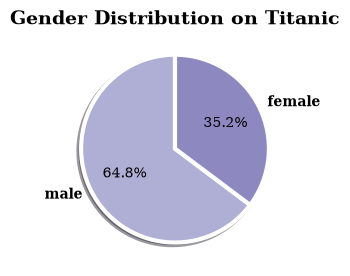

In [245]:
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.figure(figsize=(3.5,3.5))
sex_counts = df['Sex'].value_counts()
color = sns.color_palette('Purples')[2:4]
wedges, texts, autotexts = plt.pie(sex_counts, labels= sex_counts.index, colors= color, startangle= 90, wedgeprops={'edgecolor' : 'white', 'linewidth' : 3},autopct= '%1.1f%%', shadow= True)
for t in texts:
    t.set_fontfamily('serif')
    t.set_fontweight('semibold')
for at in autotexts:
    at.set_fontfamily('serif')
plt.title('Gender Distribution on Titanic', pad= 5, fontsize= 14, fontfamily= 'serif', fontweight= 'bold')
plt.tight_layout(pad=3)
plt.show()


NUMBER OF DEATHS VS SURVIVED

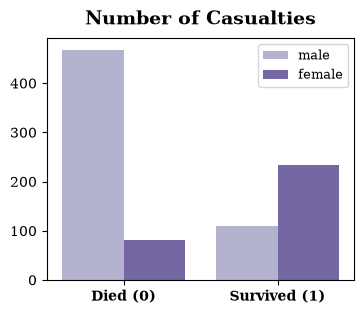

In [246]:
plt.figure(figsize=(4,3.5))
color_palette = sns.color_palette('Purples', n_colors= 6).as_hex()
color = {'male': color_palette[2], 'female': color_palette[4]}
sns.countplot(data=df, x= 'Survived', hue= 'Sex', palette= color)
plt.title('Number of Casualties', pad= 10, fontfamily= 'serif', fontweight= 'bold', fontsize= 14)
plt.yticks(fontfamily= 'serif', fontsize= 10)
plt.xticks(ticks=[0,1], labels=['Died (0)', 'Survived (1)'], fontfamily= 'serif', fontsize= 10,  fontweight= 'semibold')
plt.legend(prop= {'family' : 'serif', 'size': 9})
plt.xlabel('')
plt.ylabel('')
plt.tight_layout(pad=2)
plt.show()

DISTRIBUTION OF PASSENGERS BY FARE

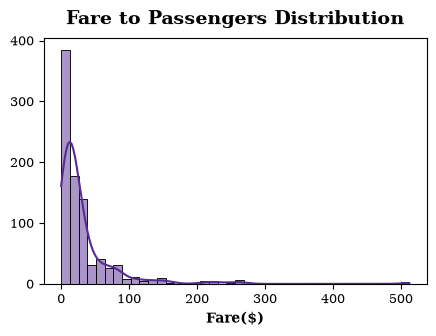

In [247]:
plt.figure(figsize=(5,4))
sns.histplot(df['Fare'], kde= True, color= color_palette[5], bins= 40)
plt.ylabel('')
plt.xlabel('Fare($)', fontfamily= 'serif', fontsize= 10, fontweight= 'semibold')
plt.xticks(fontfamily= 'serif', fontsize= 9)
plt.yticks(fontfamily= 'serif', fontsize= 9)
plt.title('Fare to Passengers Distribution', fontfamily= 'serif', fontsize= 14, fontweight= 'bold', pad= 10)
plt.tight_layout(pad=3)
plt.show() #distribution was right skewwed.

DISTRIBUTION OF AGE GRADES ONBOARD 

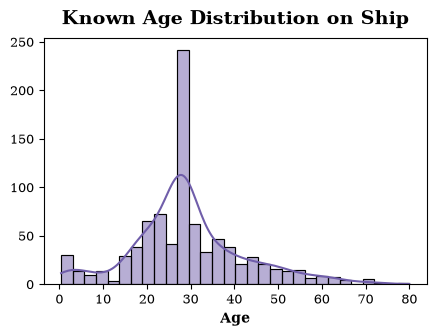

In [248]:
plt.figure(figsize=(5,4))
sns.histplot(df['Age'], kde= True, bins= 30, color= color_palette[4])
plt.ylabel('')
plt.xlabel('Age', fontfamily= 'serif', fontsize= 10, fontweight= 'semibold')
plt.xticks(fontfamily= 'serif', fontsize= 9)
plt.yticks(fontfamily= 'serif', fontsize= 9)
plt.title('Known Age Distribution on Ship', fontfamily= 'serif', fontsize= 14, fontweight= 'bold', pad= 10)
plt.tight_layout(pad=3)
plt.show() #The ages are also right skewwed

COMPARISON OF PASSENGER EMBARKED LOCATIONS

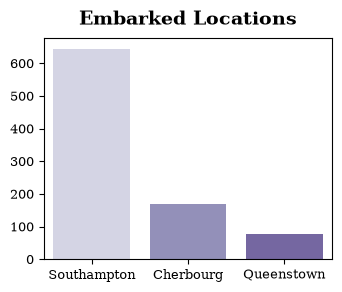

In [249]:
plt.figure(figsize=(3.5,3))
embarked_counts = df['Embarked'].value_counts()
color = {'S' : color_palette[1], 'C' : color_palette[3], 'Q' : color_palette[4], 'Un' : color_palette[5] }
#here i removed the unspecified data because it contained only 2 values and would not be visible on the chart, hence insignificant.
sns.countplot(data= df[df['Embarked'] != 'Un'], x= 'Embarked', hue= 'Embarked', palette= color )
plt.title('Embarked Locations', fontfamily= 'serif', fontsize= 14, fontweight= 'bold', pad=10 )
plt.ylabel('')
plt.xlabel('')
plt.xticks(ticks=[0,1,2], labels=['Southampton', 'Cherbourg', 'Queenstown'], fontfamily= 'serif', fontsize= 9)
plt.yticks(fontfamily= 'serif', fontsize= 9)
plt.tight_layout(pad=1)
plt.show()

CORRELATION BETWEEN PCLASS AND FARE

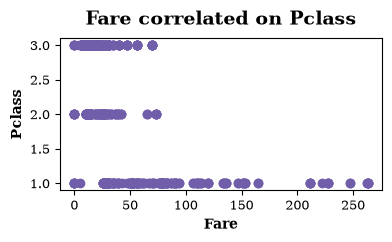

In [250]:
from scipy.stats import linregress
plt.figure(figsize=(4,2.5))
filtered = df[df['Fare'] < 500] #Removed extreme outliers to get a better view
plt.scatter(filtered['Fare'], filtered['Pclass'], color= color_palette[4])
plt.ylabel('Pclass', fontfamily= 'serif', fontsize= 10, fontweight= 'semibold')
plt.xlabel('Fare', fontfamily= 'serif', fontsize= 10, fontweight= 'semibold' )
plt.title('Fare correlated on Pclass',  fontfamily= 'serif', fontsize= 14, fontweight= 'bold', pad= 10)
plt.xticks(fontfamily= 'serif', fontsize= 9)
plt.yticks(fontfamily= 'serif', fontsize= 9)
# lin_re = linregress(filtered['Fare'], filtered['Pclass'])
# slope = lin_re.slope
# intercept = lin_re.intercept
# plt.plot(filtered['Fare'], (slope * filtered['Fare'] + intercept), color = color_palette[5], linewidth= 1, linestyle= '--')
plt.tight_layout(pad=1)
plt.show()

In [251]:
sns.color_palette('Purples')

[(0.9265974625144175, 0.919769319492503, 0.9557093425605536),
 (0.8207612456747405, 0.8218992695117262, 0.9044982698961938),
 (0.6878892733564014, 0.6835832372164552, 0.829834678969627),
 (0.5513264129181085, 0.537916186082276, 0.7524490580545944),
 (0.440722798923491, 0.36772010765090346, 0.6653902345251825),
 (0.3405767012687428, 0.1742560553633218, 0.5709342560553633)]

STEP 4: PREPARATION FOR MODELING

ONE-HOT ENCODING

In [ ]:
#Our target column(Survived) is already encoded with 0 and 1.

#to one-hot encode our features (Sex) and (Embarked)
df_encoded = pd.get_dummies(df[df['Embarked'] != 'Un'].drop(columns=['Sex_Transformed', 'Embarked_Transformed']), columns= ['Sex', 'Embarked'], drop_first=True)
#Pclass and Fare don't need one-hot encoding.
df_encoded

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,True,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",28.0,1,2,W./C. 6607,23.4500,NaN,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,True,False,False


SPLIT INTO FEATURES(X) AND TARGET(Y)

In [350]:
X = df_encoded[['Sex_male', 'Pclass', 'Fare', 'Embarked_Q', 'Embarked_S', 'Age', 'SibSp', 'Parch']]
y = df_encoded['Survived']

TRAIN/TEST SPLIT

In [351]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)

SCALING NUMERIC FEATURES

In [352]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

STEP 5: TRAINING A MODEL

In [353]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter= 1000)
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)


SIMULATED PREDICTIONS

In [354]:
print(f'Predictions: {predictions}')
print(f'y_test: {y_test.to_numpy()}')

Predictions: [0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0 0
 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 0
 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 0
 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0]
y_test: [0 0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 0 0
 0 0 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0 1
 1 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0]


STEP 6: EVALUATE

In [355]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
print(f'Accuracy: {round(accuracy * 100, 1)}%')
print()
print(f'Confusion matrix: \n{cm}') 
# [[TN  FP]
# [FN  TP]]


Accuracy: 80.9%

Confusion matrix: 
[[97 13]
 [21 47]]


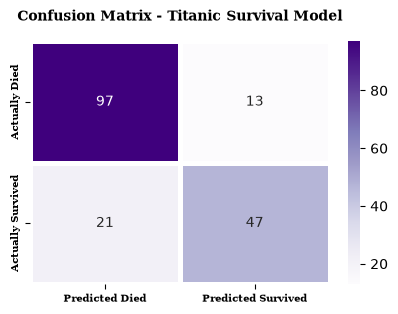

In [356]:
plt.figure(figsize=(4.5,3.5))
sns.heatmap(cm, annot= True, fmt= 'd', cmap= 'Purples', xticklabels= ['Predicted Died', 'Predicted Survived'], yticklabels= ['Actually Died', 'Actually Survived'], annot_kws= {'size' : 10}, linewidths= 2.5)

plt.title('Confusion Matrix - Titanic Survival Model', fontfamily= 'serif', fontsize= 10, fontweight= 'bold', pad= 15)
plt.xticks(fontfamily= 'serif', fontsize= 7, fontweight= 'semibold')
plt.yticks(fontfamily= 'serif', fontsize= 7, fontweight= 'semibold')
plt.tight_layout(pad=2)
plt.show()


In [359]:
print(f'Number of passengers used for test: {y_test.shape[0]}')
print('This means that out of the 178 passengers that were used to test out model, we correctly predicted the survival of 47 passengers, and death of 97 passengers')
print('However, we wrongly predicted the death of 21 and survival of 13')

Number of passengers used for test: 178
This means that out of the 178 passengers that were used to test out model, we correctly predicted the survival of 47 passengers, and death of 97 passengers
However, we wrongly predicted the death of 21 and survival of 13


STEP 7: SUMMARY